# Лабораторная работа 1
## Вариант 5



## Задание 1

Для задачи своего варианта необходимо:

1. Определить, что выполняет приведённая функция.
2. Определить вычислительную сложность алгоритма в O-нотации.
3. Построить график времени выполнения функции при увеличении входных данных.

### Вариант 5

Функция получает список чисел. Она проходит по элементам списка и проверяет каждый элемент. Если встречается чётное число, функция сразу возвращает `True`. Если весь список просмотрен и чётных чисел нет, возвращается `False`.

**Сложность:** в худшем случае `O(n)`, потому что приходится проверить все `n` элементов. В лучшем случае `O(1)`, если первый элемент уже чётный.

In [2]:
def foo(nums):
    for x in nums:
        if x % 2 == 0:
            return True
    else:
        return False


print(foo([1, 3, 5, 8, 9]))
print(foo([1, 3, 5, 7, 9]))

True
False


### Измерение времени выполнения


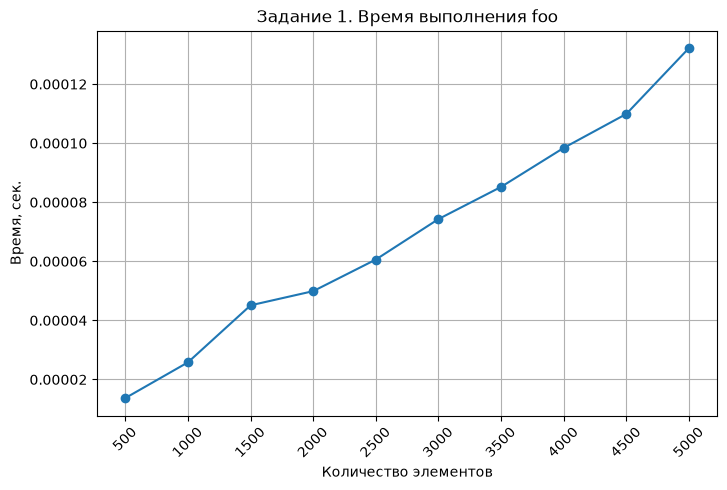

In [ ]:
import time
import matplotlib.pyplot as plt

sizes = list(range(500, 5001, 500))
times_foo = []

for n in sizes:
    data = [2 * i + 1 for i in range(n)]

    start = time.perf_counter()
    foo(data)
    finish = time.perf_counter()

    times_foo.append(finish - start)

plt.figure(figsize=(8, 5))
plt.plot(sizes, times_foo, marker="o")
plt.xlabel("Количество элементов")
plt.ylabel("Время, сек.")
plt.title("Задание 1. Время выполнения foo")
plt.xticks(sizes, rotation=45)
plt.grid(True) 
plt.show()

Функция проверяет наличие хотя бы одного чётного элемента в списке. В худшем случае она просматривает весь список, поэтому имеет линейную сложность `O(n)`. При увеличении размера списка время выполнения в целом увеличивается.

# Задание 2

Дана строка. Необходимо определить, какая буква встречается чаще всего.



## Алгоритм 1 — подсчёт с помощью словаря

Создаём словарь, где ключом является буква, а значением — количество её появлений.

**Сложность:** `O(n)`, где `n` — длина строки. Каждый символ обрабатывается один раз.

In [6]:
def most_frequent_dict(s):
    counts = {}

    for char in s:
        counts[char] = counts.get(char, 0) + 1

    most_common = None
    max_count = 0

    for char in s:
        if counts[char] > max_count:
            most_common = char
            max_count = counts[char]

    return most_common


print(most_frequent_dict("danya-marakya"))

a


## Алгоритм 2 — подсчёт каждой уникальной буквы

Сначала получаем множество уникальных букв. Затем для каждой буквы считаем количество её появлений в строке с помощью `count()`.

**Сложность:** в худшем случае `O(n²)`, потому что для большого количества разных символов строка может просматриваться много раз.

In [7]:
def most_frequent_count(s):
    unique_chars = set(s)

    most_common = None
    max_count = 0

    for char in unique_chars:
        current_count = s.count(char)

        if current_count > max_count:
            most_common = char
            max_count = current_count

    return most_common


print(most_frequent_count("danya-marakya"))

a


### Сравнение алгоритмов

Для сравнения будем создавать строки нужной длины и измерять время выполнения обоих алгоритмов. Размер строки увеличивается с шагом 500.

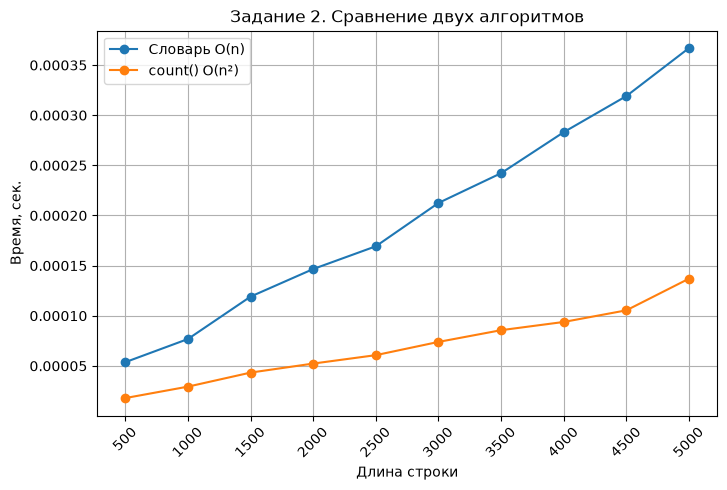

In [17]:
import random
import string
import time

random.seed(42)

sizes = list(range(500, 5001, 500))
times_dict = []
times_count = []

for n in sizes:
    s = "".join(random.choices(string.ascii_lowercase, k=n))

    start = time.perf_counter()
    most_frequent_dict(s)
    finish = time.perf_counter()
    times_dict.append(finish - start)

    start = time.perf_counter()
    most_frequent_count(s)
    finish = time.perf_counter()
    times_count.append(finish - start)


plt.figure(figsize=(8, 5))
plt.plot(sizes, times_dict, marker="o", label="Словарь O(n)")
plt.plot(sizes, times_count, marker="o", label="count() O(n²)")
plt.xlabel("Длина строки")
plt.ylabel("Время, сек.")
plt.title("Задание 2. Сравнение двух алгоритмов")
plt.xticks(sizes, rotation=45)
plt.legend()
plt.grid(True)
plt.show()


Алгоритм со словарём имеет сложность `O(n)` и обычно работает быстрее при увеличении размера строки. Второй алгоритм в худшем случае имеет сложность `O(n²)`, поэтому его время растёт быстрее.

# Задание 3

Количество операций для двух алгоритмов задано формулами:

- `T₁(N) = N² - N - 10`
- `T₂(N) = 4N + 40`

Нужно определить размер массива `N`, при котором количество операций одинаково.


In [12]:
N = 10

T1 = N**2 - N - 10
T2 = 4 * N + 40

print("N =", N)
print("T1(N) =", T1)
print("T2(N) =", T2)
print("Количество операций одинаково:", T1 == T2)

N = 10
T1(N) = 80
T2(N) = 80
Количество операций одинаково: True


# Задание 4

Проведём эксперимент и сравним производительность оператора `del` для словаря и списка.

Для честного сравнения удаляем элемент примерно из середины структуры:

- для списка — элемент с индексом `N // 2`;
- для словаря — элемент с ключом `N // 2`.



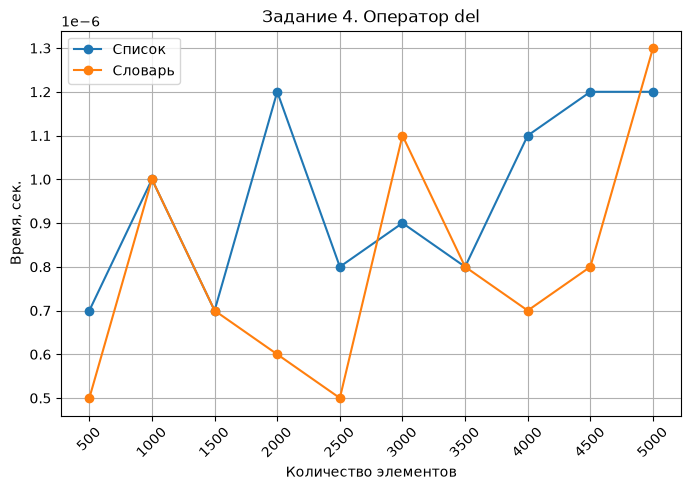

In [16]:
import timeit

sizes = list(range(500, 5001, 500))
times_del_list = []
times_del_dict = []

for n in sizes:
    list_setup = f"data = list(range({n})); index = {n // 2}"
    dict_setup = f"data = {{i: i for i in range({n})}}; key = {n // 2}"

    list_time = timeit.timeit(
        "del data[index]",
        setup=list_setup,
        number=1
    )

    dict_time = timeit.timeit(
        "del data[key]",
        setup=dict_setup,
        number=1
    )

    times_del_list.append(list_time)
    times_del_dict.append(dict_time)


plt.figure(figsize=(8, 5))
plt.plot(sizes, times_del_list, marker="o", label="Список")
plt.plot(sizes, times_del_dict, marker="o", label="Словарь")
plt.xlabel("Количество элементов")
plt.ylabel("Время, сек.")
plt.title("Задание 4. Оператор del")
plt.xticks(sizes, rotation=45)
plt.legend()
plt.grid(True)
plt.show()

# Задание 5

Сравним производительность оператора `in` для множества и списка.

Проверять будем наличие элемента, которого нет в структуре

- для списка проверка `in` имеет сложность `O(n)`;
- для множества проверка `in` в среднем имеет сложность `O(1)`.

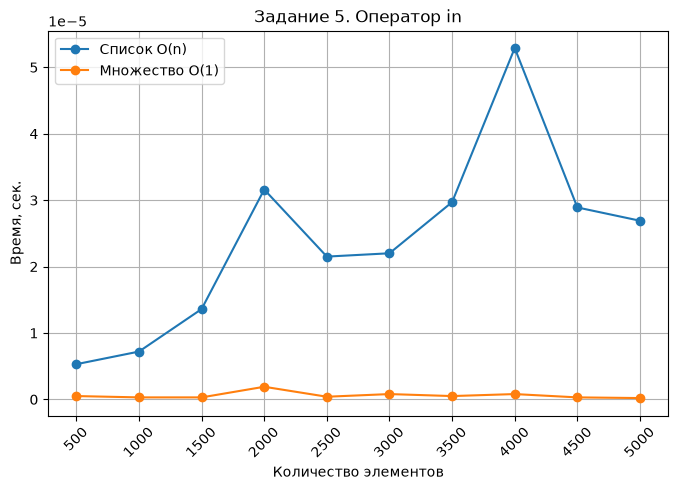

In [20]:
sizes = list(range(500, 5001, 500))
times_in_list = []
times_in_set = []

for n in sizes:
    list_data = list(range(n))
    set_data = set(range(n))
    value = -1  # такого элемента нет

    list_time = timeit.timeit(
        "value in data",
        setup="",
        number=1,
        globals={"data": list_data, "value": value}
    )

    set_time = timeit.timeit(
        "value in data",
        setup="",
        number=1,
        globals={"data": set_data, "value": value}
    )

    times_in_list.append(list_time)
    times_in_set.append(set_time)


plt.figure(figsize=(8, 5))
plt.plot(sizes, times_in_list, marker="o", label="Список O(n)")
plt.plot(sizes, times_in_set, marker="o", label="Множество O(1)")
plt.xlabel("Количество элементов")
plt.ylabel("Время, сек.")
plt.title("Задание 5. Оператор in")
plt.xticks(sizes, rotation=45)
plt.legend()
plt.grid(True)
plt.show()

Проверка принадлежности для множества в среднем выполняется за `O(1)`, поэтому размер множества оказывает небольшое влияние на время. Для списка сложность `O(n)`, так как при отсутствии элемента необходимо проверить все элементы.